# **Install required libraries**

In [ ]:
!pip install -q PyMuPDF spacy
!python -m spacy download en_core_web_sm
!pip install pdfplumber python-docx pytesseract Pillow
!apt install tesseract-ocr -y


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 42.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


# ***Load the Resume Folder***

In [ ]:
from google.colab import drive
# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Set the folder path in Drive where resumes are stored
resume_folder = '/content/drive/MyDrive/Resume'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Extraction of Text**

In [ ]:
import os
import pdfplumber
import docx
import pytesseract
from PIL import Image

# 1. Function to extract text from PDF
def extract_text_from_pdf(pdf_path):
    text = ''
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            text += page.extract_text() or ''
    return text

# 2. Function to extract text from DOCX
def extract_text_from_docx(docx_path):
    doc = docx.Document(docx_path)
    return '\n'.join([para.text for para in doc.paragraphs])

# 3. Function to extract text from TXT
def extract_text_from_txt(txt_path):
    with open(txt_path, 'r', encoding='utf-8') as file:
        return file.read()

# 4. Function to extract text from image
def extract_text_from_image(image_path):
    image = Image.open(image_path)
    return pytesseract.image_to_string(image)

# 5. Master function to extract text from any resume
def extract_resume_text(file_path):
    file_path_lower = file_path.lower()
    if file_path_lower.endswith('.pdf'):
        return extract_text_from_pdf(file_path)
    elif file_path_lower.endswith('.docx'):
        return extract_text_from_docx(file_path)
    elif file_path_lower.endswith('.txt'):
        return extract_text_from_txt(file_path)
    elif file_path_lower.endswith(('.jpg', '.jpeg', '.png')):
        return extract_text_from_image(file_path)
    else:
        return "❌ Unsupported file format"

# 6. Process all files in the folder
resume_texts = {}
for filename in os.listdir(resume_folder):
    file_path = os.path.join(resume_folder, filename)
    if os.path.isfile(file_path):
        text = extract_resume_text(file_path)
        resume_texts[filename] = text

# Extract the info

**SpaCy Model**

In [ ]:
import re
import spacy
from datetime import datetime
from dateutil import parser as date_parser

nlp = spacy.load("en_core_web_sm")

skills_list = [
    "python", "machine learning", "data analysis", "scikit-learn", "tensorflow", "pytorch", "nlp", "ai",
    "html", "css", "javascript", "flask", "django", "react", "node", "api", "frontend", "backend",
    "docker", "kubernetes", "jenkins", "aws", "git", "ci/cd", "linux",
    "flutter", "android", "kotlin", "swift", "react native",
    "sql", "postgresql", "mysql", "nosql", "mongodb", "oracle",
    "java", "restful",
    "user research", "wireframing", "prototyping", "figma", "adobe xd", "sketch",
    "usability testing", "information architecture", "interaction design", "visual design", "accessibility",
    "penetration testing", "vulnerability assessment", "firewalls", "siem", "ids/ips",
    "network security", "cryptography", "incident response", "risk assessment", "compliance", "nmap",
    "azure", "gcp", "terraform", "ansible", "cloudformation", "devops", "cloud security",
    "serverless", "cloud architecture",
    "requirement gathering", "excel", "business process modeling", "user stories",
    "jira", "agile", "stakeholder communication", "gap analysis",
    "seo", "sem", "google ads", "facebook ads", "content marketing", "email marketing",
    "analytics", "social media", "wordpress", "crm", "a/b testing", "conversion optimization",
    "roadmapping", "market research", "scrum", "kanban", "feature prioritization",
    "product lifecycle", "kpis", "stakeholder management",
    "solidworks", "autocad", "fea", "cfd", "manufacturing", "materials science",
    "mechanical design", "ansys", "3d modeling", "cam", "matlab",
    "circuit design", "pcb", "vhdl", "verilog", "embedded systems", "simulink",
    "arduino", "raspberry pi", "power systems", "control systems",
    "copywriting", "seo writing", "blogging", "technical writing", "editing", "proofreading",
    "content strategy", "creative writing", "tone adaptation",
    "lesson planning", "curriculum design", "assessment", "classroom management", "edtech tools",
    "communication", "student engagement", "online teaching", "pedagogy", "differentiated instruction"
]

**Normalize Function**

In [ ]:
def normalize_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text

**Extract specific sections**

In [ ]:
def extract_sections(text, keywords):
    sections = {}
    lines = text.split('\n')
    current_key = None
    buffer = []

    for line in lines:
        stripped = line.strip().lower()
        for key in keywords:
            if key in stripped:
                if current_key and buffer:
                    sections[current_key] = '\n'.join(buffer).strip()
                current_key = key
                buffer = []
                break
        else:
            if current_key:
                buffer.append(line)
    if current_key and buffer:
        sections[current_key] = '\n'.join(buffer).strip()

    return sections

**Extract years**

In [ ]:
def extract_years_from_dates(text):
    total_years = 0
    matches = re.findall(r'(\w+\s\d{4})\s*[-–to]{1,3}\s*(\w+\s\d{4}|present)', text, re.IGNORECASE)

    for start, end in matches:
        try:
            start_date = date_parser.parse(start)
            end_date = datetime.now() if 'present' in end.lower() else date_parser.parse(end)
            if start_date < end_date:
                total_years += (end_date.year - start_date.year)
        except Exception:
            continue
    return total_years

**Extraction**

In [ ]:
def extract_info(text):
    raw_text = text
    text_clean = normalize_text(text)
    doc = nlp(raw_text)
    lines = raw_text.split('\n')

    # Name
    name = "N/A"
    invalid_keywords = ["resume", "cv", "developer", "engineer", "linkedin", "email"]

    for ent in doc.ents:
        if ent.label_ == "PERSON" and 1 <= len(ent.text.split()) <= 3 and not any(k in ent.text.lower() for k in invalid_keywords):
            name = ent.text.strip()
            break

    if name == "N/A":
        for line in lines[:5]:
            if line.strip() and not any(k in line.lower() for k in invalid_keywords):
                words = line.strip().split()
                if 1 <= len(words) <= 3:
                    name = ' '.join(word.title() for word in words)
                    break

    if name == "N/A":
        matches = re.findall(r'\b[A-Z][a-z]+ [A-Z][a-z]+\b', raw_text)
        if matches:
            name = matches[0].strip()
    # Contact Info
    email = re.findall(r'[\w\.-]+@[\w\.-]+', raw_text)
    phone = re.findall(r'\+?\d[\d\s\-()]{7,}\d', raw_text)

    #Skills
    skill_text = raw_text.lower().replace("-", " ")
    skills = [skill for skill in skills_list if skill in skill_text]

    # Years of Experience
    years_kw = re.findall(r'(\d{1,2}(?:\.\d{1,2})?)\s*(?:\+?\s*)?(?:years?|yrs?)', raw_text.lower())
    years_from_kw = max([float(yr) for yr in years_kw if float(yr) < 40], default=0)

    years_from_dates = extract_years_from_dates(raw_text)
    experience_years = int(max(years_from_kw, years_from_dates))

    # CGPA
    cgpa_match = re.search(r'\b(?:cgpa|gpa)[\s:\-]*([0-4]\.\d{1,2})', raw_text, re.IGNORECASE)
    cgpa = cgpa_match.group(1) if cgpa_match else "N/A"

    # Section Extraction
    section_keys = [
        'education', 'project', 'projects', 'experience', 'work experience', 'employment history',
        'professional experience', 'achievements', 'internships', 'certifications'
    ]
    sections = extract_sections(text_clean, section_keys)

    def get_section(*keys):
        for key in keys:
            if key in sections:
                return sections[key]
        return "N/A"

    return {
        "Name": name,
        "Email": email[0] if email else "N/A",
        "Phone": phone[0] if phone else "N/A",
        "Skills": skills,
        "CGPA": cgpa,
        "ExperienceYears": experience_years,
        "Education": get_section("education"),
        "Projects": get_section("project", "projects"),
        "Achievements": get_section("achievements"),
        "ExperienceDetails": get_section("experience", "work experience", "professional experience", "employment history", "internships"),
        "Text": text_clean
    }

****

**List to hold each resume's extracted info**

In [ ]:
data = []

for filename, text in resume_texts.items():
    info = extract_info(text)
    info["Filename"] = filename
    data.append(info)

In [ ]:
import pandas as pd
df = pd.DataFrame(data)

df = df[[
    "Filename","Name", "Email", "Phone", "CGPA", "ExperienceYears",
    "Skills", "Education", "Projects", "Achievements", "ExperienceDetails"
]]

df.to_csv("extracted_resume_data.csv", index=False)
df.head(15)

,Filename,Name,Email,Phone,CGPA,ExperienceYears,Skills,Education,Projects,Achievements,ExperienceDetails
0,AddisonHarrisResume.pdf,Cloud Architecture,help@enhancv.com,N/A,N/A,5,"[ai, react, aws, git, compliance, azure, cloud...",university of cincinnati cincinnati oh\nbachel...,on enhancing efficiency and scalability cloud ...,excellence in cloud migration speaker at clou...,tech innovators inc remote\nsenior cloud solut...
1,Shifat Ahmed_CV.pdf,Shifat Ahmed Skills,ahmed15-5214@diu.edu.bd,01782843942,3.82,3,[ai],personal qualification\ninformation\nbacheloro...,N/A,N/A,months\ncompany abt global llc\nshifat ahmed s...
2,skill-based-resume-template.png,Frank Graham,frank@novoresume.com,123 444 555,N/A,8,"[ai, excel]",N/A,N/A,devised and implemented an effective sales pro...,customer service \n sales associate\n\ncustome...
3,Ashok Jayakumar - PM.docx,Module Lead,Venkat@infoservicesllc.com,734-259-2421,N/A,12,"[ai, html, backend, linux, sql, java, complian...",bachelor of engineering in computer science an...,technology web services xml java java script ...,N/A,provide visual concepts and system behavior
4,Abiral_Pandey_Fullstack_Java.docx,Visa Status,abiral.pandey88@gmail.com,940-242-3303,N/A,13,"[ai, html, css, javascript, node, api, backend...",bachelor of computer science university of no...,used jenkins for continuous integration\nused ...,N/A,implemented unit and integration test cases wi...
5,BA - Navneet.docx,Waterfall Model,11baconsultant@outlook.com,407-401-9023,N/A,15,"[data analysis, ai, html, javascript, api, bac...",,followed the agile methodology during the enti...,N/A,data mapping for captured source and destinati...
6,Akhil_Sr BSA.docx,Akhil,akhil.mohan0109@gmail.com,510-953-0677,N/A,8,"[data analysis, ai, html, css, sql, oracle, ja...",N/A,,N/A,client jpmorgan chase\tmarch 2016 to till dat...
7,Alekhya Resume.docx,Java,alekhya.workmail@gmail.com,515)-518-0849,N/A,8,"[ai, html, css, javascript, react, node, api, ...",N/A,used svn to checkin and checkout and coordinat...,N/A,developed different gui screens using widgets ...
8,Akhil.profile.docx,Akhil,akhil.mohan0109@gmail.com,510-953-0677,N/A,8,"[data analysis, ai, html, css, api, sql, oracl...",N/A,,N/A,client jpmorgan chase\t ...
9,Anudeep N_Sr Java Developer.docx,Java,anudeepreddynallamada@gmail.com,N/A,N/A,8,"[ai, html, css, javascript, react, node, api, ...",bachelor of engineering in computer science an...,created images logos and icons that are used a...,N/A,environment java j2ee spring framework html ja...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Filename           234 non-null    object
 1   Name               234 non-null    object
 2   Email              234 non-null    object
 3   Phone              234 non-null    object
 4   CGPA               234 non-null    object
 5   ExperienceYears    234 non-null    int64 
 6   Skills             234 non-null    object
 7   Education          234 non-null    object
 8   Projects           234 non-null    object
 9   Achievements       234 non-null    object
 10  ExperienceDetails  234 non-null    object
dtypes: int64(1), object(10)
memory usage: 20.2+ KB


**Years of Experience vs Number of Projects**

/tmp/ipython-input-1270817452.py:12: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



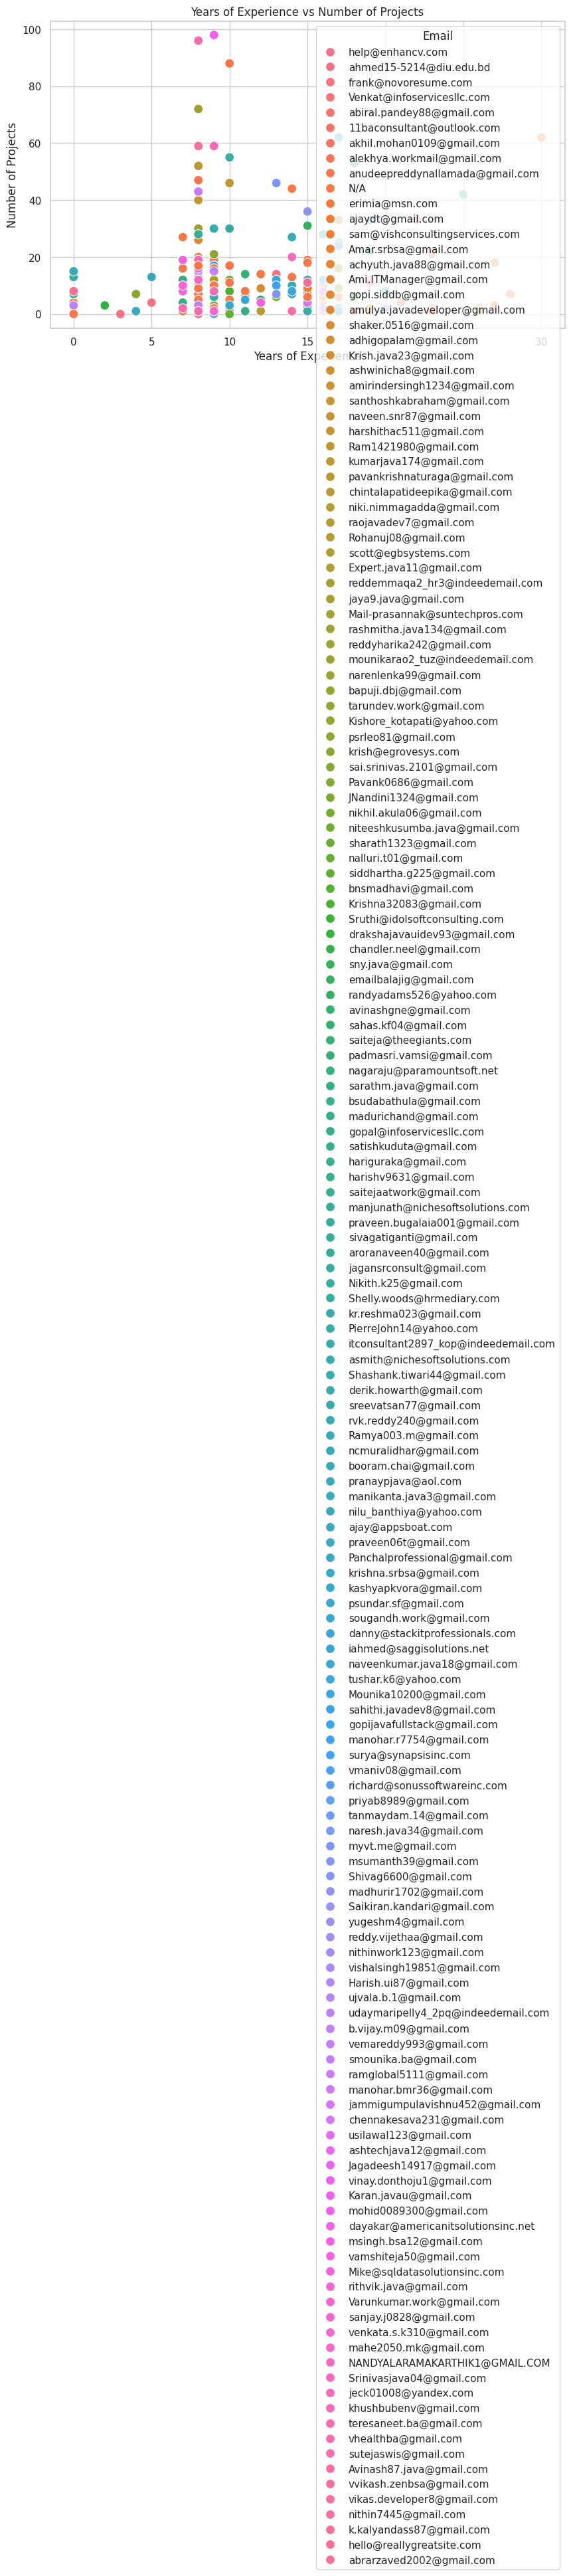

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df["ProjectCount"] = df["Projects"].apply(lambda x: len(x.split('\n')) if isinstance(x, str) and x.strip() != "N/A" else 0)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="ExperienceYears", y="ProjectCount", hue="Email", s=100)
plt.title("Years of Experience vs Number of Projects")
plt.xlabel("Years of Experience")
plt.ylabel("Number of Projects")
plt.grid(True)
plt.tight_layout()
plt.show()


**Job Experience Detail vs Key Achievements**

/tmp/ipython-input-4114499629.py:10: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



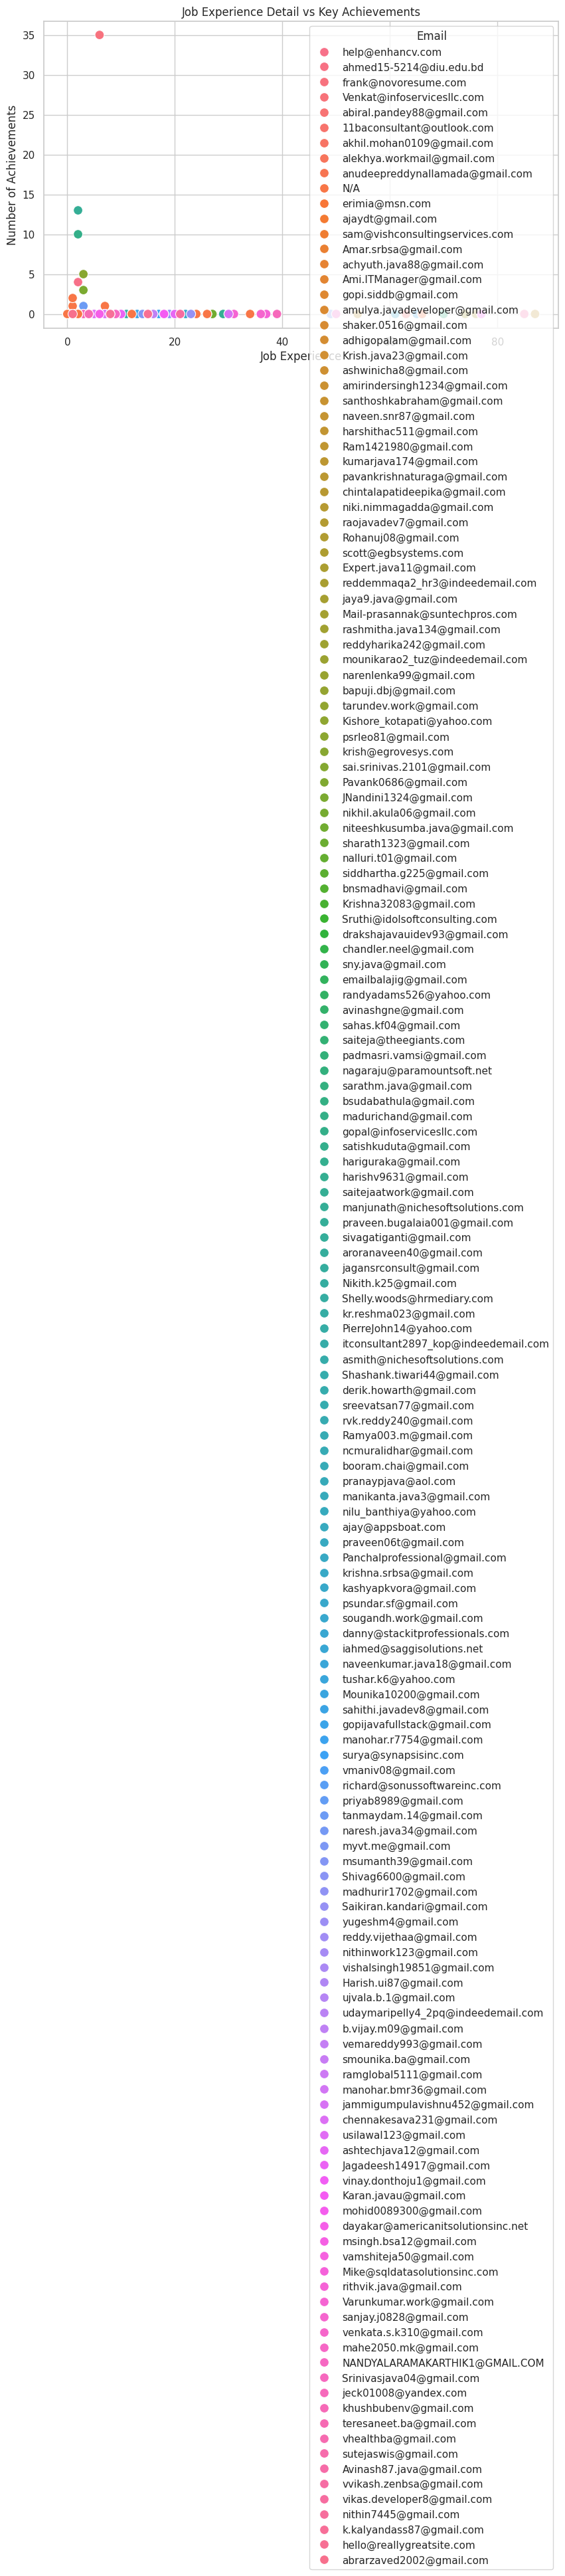

In [ ]:
df["ExperienceLineCount"] = df["ExperienceDetails"].apply(lambda x: len(x.split('\n')) if isinstance(x, str) and x.strip() != "N/A" else 0)
df["AchievementCount"] = df["Achievements"].apply(lambda x: len(x.split('\n')) if isinstance(x, str) and x.strip() != "N/A" else 0)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="ExperienceLineCount", y="AchievementCount", hue="Email", s=100)
plt.title("Job Experience Detail vs Key Achievements")
plt.xlabel("Job Experience")
plt.ylabel("Number of Achievements")
plt.grid(True)
plt.tight_layout()
plt.show()


***Job Categories Declaration***

In [ ]:
job_categories = {
     "Data Scientist": ["python", "machine learning", "data analysis", "scikit-learn", "tensorflow", "pytorch", "nlp", "ai"],
    "AI/ML Engineer": [
        "machine learning", "deep learning", "neural networks", "pytorch", "tensorflow",
        "scikit-learn", "keras", "opencv", "reinforcement learning", "nlp", "computer vision"
    ],
    "Business Analyst": [
        "excel", "power bi", "tableau", "sql", "data visualization", "data modeling",
        "requirements gathering", "business process modeling", "gap analysis", "statistics"
    ],
    "Cybersecurity Analyst": [
        "network security", "penetration testing", "vulnerability assessment", "firewalls",
        "ids/ips", "risk assessment", "incident response", "wireshark", "encryption", "nmap"
    ],
    "Cloud Engineer": [
        "aws", "azure", "gcp", "terraform", "cloudformation", "devops", "docker", "kubernetes",
        "serverless", "cloud storage", "lambda", "cloud networking"
    ],
    "UI/UX Designer": [
        "user research", "wireframing", "prototyping", "figma", "adobe xd", "usability testing",
        "interaction design", "responsive design", "design systems", "a/b testing"
    ],
    "Product Manager": [
        "roadmapping", "agile", "scrum", "kanban", "market research", "jira", "confluence",
        "stakeholder management", "feature prioritization", "go-to-market strategy"
    ],
    "QA Engineer": [
        "manual testing", "automation testing", "selenium", "junit", "testng", "bug tracking",
        "regression testing", "performance testing", "test case writing", "api testing"
    ],
    "Systems Administrator": [
        "linux", "windows server", "bash", "powershell", "active directory", "virtualization",
        "vmware", "hyper-v", "network configuration", "system monitoring"
    ],
    "Embedded Systems Engineer": [
        "c", "c++", "embedded c", "microcontrollers", "rtos", "arduino", "raspberry pi",
        "firmware development", "hardware debugging", "spi", "uart", "i2c"
    ],
    "Digital Marketer": [
        "seo", "sem", "google analytics", "facebook ads", "email marketing", "content strategy",
        "wordpress", "social media marketing", "ppc", "affiliate marketing"
    ],
    "Network Engineer": [
        "tcp/ip", "dns", "dhcp", "routing", "switching", "firewalls", "vpn", "load balancers",
        "network monitoring", "cisco", "juniper", "network security"
    ],
    "Game Developer": [
        "unity", "unreal engine", "c#", "c++", "game physics", "3d modeling", "animation",
        "shader programming", "game design", "vr/ar", "level design", "multiplayer networking"
    ],
    "Technical Writer": [
        "technical documentation", "api documentation", "markdown", "latex", "xml", "dita",
        "content management", "information architecture", "editorial skills", "software manuals"
    ],
    "Data Engineer": [
        "etl", "apache spark", "hadoop", "airflow", "sql", "python", "scala", "data pipelines",
        "big data", "data warehousing", "snowflake", "redshift", "data lakes"
    ],
    "AI Researcher": [
        "research papers", "theoretical ai", "mathematical modeling", "optimization",
        "probability", "linear algebra", "deep learning", "generative models", "reinforcement learning", "publication"
    ],
    "IT Support Specialist": [
        "troubleshooting", "ticketing systems", "hardware support", "software installation",
        "network support", "customer service", "windows", "mac os", "active directory", "remote assistance"
    ],
    "Bioinformatics Specialist": [
        "python", "r", "bioconductor", "genomics", "sequence alignment", "bioinformatics tools",
        "machine learning", "data visualization", "biological databases", "next-generation sequencing"
    ],
    "HR Manager": [
        "recruitment", "onboarding", "employee relations", "performance management", "hr policies",
        "compliance", "payroll", "training and development", "talent acquisition", "hrms"
    ],
    "Financial Analyst": [
        "financial modeling", "excel", "vba", "forecasting", "budgeting", "power bi", "tableau",
        "investment analysis", "accounting", "ratio analysis", "valuation", "sql"
    ],
    "Legal Advisor": [
        "contract law", "corporate law", "litigation", "compliance", "legal research", "negotiation",
        "risk management", "intellectual property", "case management", "legal documentation"
    ],
    "Cybersecurity Specialist": [
        "penetration testing", "vulnerability assessment", "firewalls", "siem", "ids/ips",
        "network security", "cryptography", "incident response", "risk assessment", "compliance", "linux", "nmap"
    ],
    "Cloud Engineer": [
        "aws", "azure", "gcp", "terraform", "ansible", "cloudformation", "devops", "cloud security",
        "kubernetes", "docker", "serverless", "cloud architecture"
    ],
    "Business Analyst": [
        "requirement gathering", "data analysis", "sql", "excel", "business process modeling", "user stories",
        "jira", "agile", "stakeholder communication", "gap analysis", "wireframing"
    ],
    "Digital Marketing Specialist": [
        "seo", "sem", "google ads", "facebook ads", "content marketing", "email marketing",
        "analytics", "social media", "wordpress", "crm", "a/b testing", "conversion optimization"
    ],
    "Product Manager": [
        "roadmapping", "market research", "agile", "scrum", "kanban", "feature prioritization",
        "wireframing", "product lifecycle", "kpis", "stakeholder management", "user stories", "jira"
    ],
    "Mechanical Engineer": [
        "solidworks", "autocad", "fea", "cfd", "manufacturing", "materials science",
        "mechanical design", "ansys", "3d modeling", "cam", "matlab"
    ],
    "Electrical Engineer": [
        "circuit design", "pcb", "vhdl", "verilog", "embedded systems", "matlab", "simulink",
        "arduino", "raspberry pi", "power systems", "control systems"
    ],
    "Content Writer": [
        "copywriting", "seo writing", "blogging", "technical writing", "editing", "proofreading",
        "wordpress", "content strategy", "creative writing", "tone adaptation"
    ],
    "Teacher / Educator": [
        "lesson planning", "curriculum design", "assessment", "classroom management", "edtech tools",
        "communication", "student engagement", "online teaching", "pedagogy", "differentiated instruction"
    ]
}


In [ ]:
def categorize_resume(skills, categories):
    score_map = {category: 0 for category in categories}
    for category, cat_skills in categories.items():
        score_map[category] = len(set(skills).intersection(set(cat_skills)))

    best_fit = max(score_map, key=score_map.get)
    return best_fit if score_map[best_fit] > 0 else "Uncategorized"


**Categorize based on skills**

In [ ]:
data = []

for filename, text in resume_texts.items():
    info = extract_info(text)

    resume_skills = info.get("Skills", [])
    category = categorize_resume(resume_skills, job_categories)
    info["Category"] = category
    info["Filename"] = filename

    data.append(info)

In [ ]:
df = pd.DataFrame(data)

df = df[[
    "Filename", "Category", "Email", "Phone", "CGPA", "ExperienceYears",
    "Skills", "Education", "Projects", "Achievements", "ExperienceDetails"
]]


In [ ]:
df_synthetic = pd.read_csv("/content/drive/MyDrive/__Resumes__/synthetic_resumes_index_bd.csv")


In [ ]:
df_synthetic.drop(columns=['Text'], inplace=True)

In [ ]:
df_synthetic = df_synthetic[df.columns]  # match column order

In [ ]:
dfm = pd.concat([df, df_synthetic], ignore_index=True)


In [ ]:
df["Source"] = "Real"
df_synthetic["Source"] = "Synthetic"

dfm = pd.concat([df, df_synthetic], ignore_index=True)


In [ ]:
dfm.head()

,Filename,Category,Email,Phone,CGPA,ExperienceYears,Skills,Education,Projects,Achievements,ExperienceDetails,Source
0,AddisonHarrisResume.pdf,Cloud Engineer,help@enhancv.com,N/A,N/A,5,"[ai, react, aws, git, compliance, azure, cloud...",university of cincinnati cincinnati oh\nbachel...,on enhancing efficiency and scalability cloud ...,excellence in cloud migration speaker at clou...,tech innovators inc remote\nsenior cloud solut...,Real
1,Shifat Ahmed_CV.pdf,Data Scientist,ahmed15-5214@diu.edu.bd,01782843942,3.82,3,[ai],personal qualification\ninformation\nbacheloro...,N/A,N/A,months\ncompany abt global llc\nshifat ahmed s...,Real
2,skill-based-resume-template.png,Data Scientist,frank@novoresume.com,123 444 555,N/A,8,"[ai, excel]",N/A,N/A,devised and implemented an effective sales pro...,customer service \n sales associate\n\ncustome...,Real
3,Ashok Jayakumar - PM.docx,Business Analyst,Venkat@infoservicesllc.com,734-259-2421,N/A,12,"[ai, html, backend, linux, sql, java, complian...",bachelor of engineering in computer science an...,technology web services xml java java script ...,N/A,provide visual concepts and system behavior,Real
4,Abiral_Pandey_Fullstack_Java.docx,Business Analyst,abiral.pandey88@gmail.com,940-242-3303,N/A,13,"[ai, html, css, javascript, node, api, backend...",bachelor of computer science university of no...,used jenkins for continuous integration\nused ...,N/A,implemented unit and integration test cases wi...,Real


In [ ]:
dfm.shape

(2234, 12)

In [ ]:
import pandas as pd

def extract_job_category(job_description, job_categories):
    job_text = job_description.lower()
    job_skills = [skill for skill_list in job_categories.values() for skill in skill_list if skill in job_text]
    return categorize_resume(job_skills, job_categories)

def get_matched_resumes_df(job_description, resume_df, job_categories, save=True):
    # Detect target category from job description
    target_category = extract_job_category(job_description, job_categories)
    print(f"\nDetected Job Category: {target_category}")

    # Filter resumes matching that category
    matched_df = resume_df[resume_df["Category"] == target_category].reset_index(drop=True)

    if matched_df.empty:
        print("No matching resumes found.")
        return pd.DataFrame()

    # Save to CSV (optional)
    if save:
        filename = f"matched_resumes_{target_category.replace(' ', '_').replace('/', '_').lower()}.csv"
        matched_df.to_csv(filename, index=False)
        print(f"✅ DataFrame saved to: {filename}")

    return matched_df

***Job Description Input***

In [ ]:
# Let user input job category or full job description
user_choice = input("Do you want to enter a job 'category' or full 'description'? ").strip().lower()

if user_choice == "category":
    print("Available categories:", list(job_categories.keys()))
    selected_category_input = input("Enter job category: ").strip() # Use a different variable name
    # Find the exact category key regardless of case or minor spacing issues if needed,
    # but for simplicity, let's stick to exact match for now.
    selected_category = None
    for cat in job_categories:
        if cat.lower() == selected_category_input.lower():
            selected_category = cat
            break

    if selected_category in job_categories:
        target_skills = job_categories[selected_category]
        # Generate a job description from skills for extract_job_category to work
        job_description_input = " ".join(target_skills)
    else:
        raise ValueError("Invalid category selected.")

elif user_choice == "description":
    print("Enter your job description (press Enter twice to finish):")
    lines = []
    while True:
        line = input()
        if line == "":
            break
        lines.append(line)
    job_description_input = "\n".join(lines)
    # Attempt to infer the category from the job description input
    inferred_category = extract_job_category(job_description_input, job_categories)
    print(f"\nInferred Job Category based on description: {inferred_category}")

    # Ask user to confirm or choose a different category
    confirm_category = input(f"Is '{inferred_category}' the correct category? (yes/no): ").strip().lower()
    if confirm_category == 'yes':
        selected_category = inferred_category
    else:
        print("Available categories:", list(job_categories.keys()))
        selected_category_input = input("Enter the correct job category: ").strip()
        selected_category = None
        for cat in job_categories:
            if cat.lower() == selected_category_input.lower():
                selected_category = cat
                break
        if selected_category not in job_categories:
             raise ValueError("Invalid category selected.")

    target_skills = job_categories.get(selected_category, []) # Get skills for the selected category


else:
    raise ValueError("Invalid input. Please choose 'category' or 'description'.")

# Pass the job description input to the function
dff = get_matched_resumes_df(job_description_input, dfm.copy(), job_categories) # Use dfm.copy() to avoid modifying original df

# Check if the DataFrame is empty before proceeding
if dff.empty:
    print("No resumes found matching the selected category.")
else:
    # The selected_category is already determined by the user input or confirmation
    print("🎯 Selected Category:", selected_category)

    # Extract target skills for the selected category
    target_skills = job_categories.get(selected_category, [])
    print("🎯 Target Skills:", target_skills)

Do you want to enter a job 'category' or full 'description'? category
Available categories: ['Data Scientist', 'AI/ML Engineer', 'Business Analyst', 'Cybersecurity Analyst', 'Cloud Engineer', 'UI/UX Designer', 'Product Manager', 'QA Engineer', 'Systems Administrator', 'Embedded Systems Engineer', 'Digital Marketer', 'Network Engineer', 'Game Developer', 'Technical Writer', 'Data Engineer', 'AI Researcher', 'IT Support Specialist', 'Bioinformatics Specialist', 'HR Manager', 'Financial Analyst', 'Legal Advisor', 'Cybersecurity Specialist', 'Digital Marketing Specialist', 'Mechanical Engineer', 'Electrical Engineer', 'Content Writer', 'Teacher / Educator']
Enter job category: Systems Administrator

Detected Job Category: Systems Administrator
✅ DataFrame saved to: matched_resumes_systems_administrator.csv
🎯 Selected Category: Systems Administrator
🎯 Target Skills: ['linux', 'windows server', 'bash', 'powershell', 'active directory', 'virtualization', 'vmware', 'hyper-v', 'network configur

**Experience Level**

In [ ]:
def evaluate_resume_level(row):
    experience = row.get("ExperienceYears", 0)
    achievements = row.get("Achievements", "")
    projects = row.get("Projects", "")
    exp_details = row.get("ExperienceDetails", "")

    score = 0

    # Years of scoring
    if experience >= 5:
        score += 2
    elif experience >= 2:
        score += 1

    # Projects scoring
    if len(projects.split('\n')) >= 4:
        score += 2
    elif len(projects.split('\n')) >= 2:
        score += 1

    # Achievements scoring
    if achievements and achievements.lower() != "n/a":
        if len(achievements.split('\n')) >= 2:
            score += 2
        else:
            score += 1

    # Experience details scoring
    if exp_details and len(exp_details.split('\n')) >= 4:
        score += 2
    elif exp_details and len(exp_details.split('\n')) >= 2:
        score += 1

    # Final classification
    if score >= 6:
        return "Expert"
    elif score >= 3:
        return "Intermediate"
    else:
        return "Beginner"


In [ ]:
# Assuming matched_candidates_df already exists from previous steps
dff["Level"] = dff.apply(evaluate_resume_level, axis=1)
dff.head(15)


,Filename,Category,Email,Phone,CGPA,ExperienceYears,Skills,Education,Projects,Achievements,ExperienceDetails,Source,Level
0,fahim.txt,Systems Administrator,.fahim.hossain453@gmail.com,8801856981693,3.93,8,"vmware, linux, powershell, bash","IUB, BSc in Software Engineering","Project Vision: used linux, vmware, bash — red...",Google Developer Group Dhaka Volunteer,Mechanical Engineer at Bkash — 2023–2025\nEmbe...,Synthetic,Expert
1,nusrat177.txt,Systems Administrator,.nusrat.ferdous286@gmail.com,8801346537556,3.51,6,"active directory, windows server, hyper-v, lin...","AIUB, BSc in Mechanical Engineering","Project Optimus: used active directory, virtua...",Best Employee Award at previous job\nGoogle De...,QA Engineer at Pathao — 2024–2025\nFinancial A...,Synthetic,Expert
2,raisa176.txt,Systems Administrator,raisa.rahman769@gmail.com,8801900167618,3.19,7,"bash, powershell, linux, system monitoring, ne...","SUST, BSc in Electrical and Electronic Enginee...","Project Vision: used linux, hyper-v — enhanced...",Kaggle Bronze Medalist,Cybersecurity Analyst at Enosis Solutions — 20...,Synthetic,Expert
3,raisa970.txt,Systems Administrator,.raisa.ferdous250@gmail.com,8801742095481,3.79,8,"hyper-v, powershell, system monitoring, bash, ...","Daffodil International University, BSc in Mech...","Project Nova: used virtualization, linux, netw...",Kaggle Bronze Medalist\nChampion in National H...,AI Researcher at Daraz BD — 2024–2025,Synthetic,Expert
4,tazkia176.txt,Systems Administrator,tazkia.alam935@gmail.com,8801700401041,2.77,3,"system monitoring, vmware, active directory, v...","SUST, MBA in Marketing","Project Vision: used system monitoring, window...",Best Employee Award at previous job\nGoogle De...,Legal Advisor at TigerIT Bangladesh — 2022–2025,Synthetic,Intermediate
5,tahsin449.txt,Systems Administrator,tahsin.hasan331@gmail.com,8801524579889,3.65,6,"virtualization, vmware, system monitoring, hyp...","SUST, BSc in Computer Science and Engineering ...","Project Optimus: used virtualization, hyper-v,...",Google Developer Group Dhaka Volunteer\nTop pe...,UI/UX Designer at Brain Station 23 — 2024–2025...,Synthetic,Expert
6,sakib220.txt,Systems Administrator,sakib.khan499@gmail.com,8801767752401,3.15,2,"active directory, powershell, windows server, ...","Daffodil International University, BSc in Mech...","Project NeuralNet: used windows server, linux,...",Best Employee Award at previous job,Product Manager at Southtech — 2024–2025\nBusi...,Synthetic,Intermediate
7,farhan440.txt,Systems Administrator,farhan.hossain195@gmail.com,8801652023897,3.6,6,"bash, vmware, linux, network configuration, hy...","RUET, BBA in Human Resource Management","Project NeuralNet: used linux, hyper-v — autom...",Completed Coursera Professional Certificate\nC...,Cybersecurity Analyst at Pathao — 2023–2025\nP...,Synthetic,Expert
8,tahsin799.txt,Systems Administrator,.tahsin.ferdous377@gmail.com,8801681359266,3.39,5,"vmware, network configuration, powershell, vir...","CUET, LLB (Hons)","Project NeuralNet: used vmware, windows server...",Champion in National Hackathon Bangladesh\nCom...,HR Manager at Therap BD — 2022–2025,Synthetic,Intermediate
9,nusrat366.txt,Systems Administrator,.nusrat.ferdous294@gmail.com,8801426261142,3.54,2,"vmware, bash, virtualization, hyper-v, active ...","AIUB, BBA in Finance","Project Nova: used active directory, hyper-v —...",Google Developer Group Dhaka Volunteer\nBest E...,Cybersecurity Specialist at Southtech — 2023–2025,Synthetic,Intermediate


# **TF-IDF**

In [ ]:
from sentence_transformers import SentenceTransformer, util

# Match Score with TF-IDF and cosine similarity

In [ ]:
import logging
logging.getLogger("pdfminer").setLevel(logging.ERROR)
import re
import pandas as pd
import numpy as np # Import numpy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from IPython.display import display


if dff.empty:
    print("DataFrame is empty. No further processing will be done.")
    # Removed exit() to prevent stopping the kernel
else:

    df = dff.copy()
    # Handle skill matching safely
    df["SkillMatchScore"] = df["Skills"].apply(
        lambda skills: sum(1 for s in skills if s.lower() in target_skills) if isinstance(skills, list) else 0
    )

    # Count number of projects (one per line, ignoring empty lines)
    df["ProjectScore"] = df["Projects"].apply(
        lambda x: sum(1 for line in str(x).split('\n') if line.strip()) if pd.notna(x) and x.strip().lower() != "n/a" else 0
    )

    # Count number of achievements (one per line, ignoring empty lines and "N/A")
    df["AchievementScore"] = df["Achievements"].apply(
        lambda x: sum(1 for line in str(x).split('\n') if line.strip()) if pd.notna(x) and x.strip().lower() != "n/a" else 0
    )

    # Normalize experience to 0–10 scale, treating N/A or missing as 0
    df["ExperienceScore"] = df["ExperienceYears"].apply(
        lambda x: float(x) if pd.notna(x) and str(x).strip().lower() != "n/a" else 0
    )

    # Apply the capping logic element-wise using numpy.minimum
    df["CappedProjectScore"] = np.minimum(df["ProjectScore"] / 5, 1)
    df["CappedAchievementScore"] = np.minimum(df["AchievementScore"] / 5, 1)
    df["CappedExperienceScore"] = np.minimum(df["ExperienceScore"] / 10, 1)


    # --- Final Match Score ---
    df["MatchScore"] = (
        0.4 * (df["SkillMatchScore"] / max(len(target_skills), 1)) +  # avoid divide-by-zero
        0.2 * df["CappedProjectScore"] +
        0.2 * df["CappedAchievementScore"] +
        0.2 * df["CappedExperienceScore"]
    ) * 100


    df["MatchScore"] = df["MatchScore"].round(2)

    # --- Sort by score ---
    df_sorted = df.sort_values(by="MatchScore", ascending=False).reset_index(drop=True)

    # --- Display result ---
    print("Top Candidates Ranked by Match Score:")
    display(df_sorted[["Filename", "MatchScore", "ExperienceYears", "Skills", "ProjectScore", "AchievementScore"]].head(10))

Top Candidates Ranked by Match Score:


,Filename,MatchScore,ExperienceYears,Skills,ProjectScore,AchievementScore
0,shifat496.txt,44.0,8,"bash, active directory, network configuration,...",4,3
1,farhan488.txt,42.0,9,"linux, hyper-v, network configuration, windows...",3,3
2,raisa970.txt,40.0,8,"hyper-v, powershell, system monitoring, bash, ...",4,2
3,raisa886.txt,38.0,5,"windows server, powershell, hyper-v, virtualiz...",4,3
4,tazkia811.txt,38.0,9,"network configuration, linux, windows server, ...",4,1
5,sakib218.txt,38.0,7,"system monitoring, hyper-v, virtualization, vm...",3,3
6,nadia397.txt,38.0,5,"virtualization, system monitoring, powershell,...",4,3
7,fahim.txt,36.0,8,"vmware, linux, powershell, bash",4,1
8,nusrat885.txt,36.0,8,"bash, linux, system monitoring, network config...",2,3
9,mehedi329.txt,36.0,6,"hyper-v, virtualization, windows server, vmware",4,2


# **BERT Model**

In [ ]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer, util
from IPython.display import display

if dff.empty:
    print("DataFrame is empty. No further processing will be done.")
    # Removed exit() to prevent stopping the kernel
else:

# Utility to clean text
  def clean_text(text):
      text = str(text).lower()
      text = re.sub(r'[^a-zA-Z\s]', ' ', text)
      return re.sub(r'\s+', ' ', text).strip()

  # Define universal skill list
  skills_list = [
      "python", "java", "sql", "machine learning", "data analysis", "nlp", "ai",
      "flask", "django", "html", "css", "aws", "restful", "backend", "api",
      "tensorflow", "pytorch", "scikit-learn", "nosql", "mongodb", "postgresql",
      "docker", "kubernetes", "git", "jenkins"
  ]

  # Load pre-trained BERT model
  bert = SentenceTransformer('all-MiniLM-L6-v2')

  # Sample job description
  job_description = """
  We need a data scientist familiar with Python, machine learning, AI, and backend APIs.
  """

  # Compute BERT embedding for job description
  jd_embedding = bert.encode(clean_text(job_description), convert_to_tensor=True)

  # -----------------------------
  # Generate combined resume text for semantic comparison
  def generate_resume_text(row):
      fields = ["Education", "Skills", "Projects", "Achievements", "ExperienceDetails"]
      parts = []
      for field in fields:
          value = row.get(field, "")
          if isinstance(value, list):
              parts.append(" ".join(map(str, value)))
          elif isinstance(value, str) and value.lower() != "n/a":
              parts.append(value)
      return " ".join(parts)

  # Create "Text" column only for BERT
  dff["Text"] = dff.apply(generate_resume_text, axis=1)

  # -----------------------------
  # Compute semantic similarities
  similarities = []
  for resume_text in dff["Text"]:
      resume_embedding = bert.encode(clean_text(resume_text), convert_to_tensor=True)
      sim = util.cos_sim(jd_embedding, resume_embedding).item()
      similarities.append(sim)

  # Add similarity and other metrics
  dff["Similarity"] = similarities
  dff["SkillCount"] = dff["Skills"].apply(lambda x: len(x) if isinstance(x, list) else 0)
  dff["ExperienceYears"] = dff["ExperienceYears"].fillna(0).astype(float)

  # Final match score calculation
  dff["MatchScore"] = dff.apply(
      lambda row: round(100 * (
          0.8 * row["Similarity"] +
          0.1 * (row["ExperienceYears"] / 10) +
          0.1 * (row["SkillCount"] / len(skills_list))
      ), 2),
      axis=1
  )


In [ ]:
  # Sort by score
  dff = dff.sort_values(by="MatchScore", ascending=False).reset_index(drop=True)
  dff = dff.drop(columns=["Text"])
  dff = dff.head(5)
  dff

,Filename,Category,Email,Phone,CGPA,ExperienceYears,Skills,Education,Projects,Achievements,ExperienceDetails,Source,Level,Similarity,SkillCount,MatchScore
0,rafi995.txt,Systems Administrator,.rafi.miah174@gmail.com,8801675885627,3.51,8.0,"linux, vmware, network configuration, system m...","Daffodil International University, BSc in Comp...","Project NeuralNet: used vmware, linux — automa...",Best Employee Award at previous job\nGoogle De...,Technical Writer at Bkash — 2022–2025\nCyberse...,Synthetic,Expert,0.400803,0,40.06
1,tazkia811.txt,Systems Administrator,.tazkia.ferdous985@gmail.com,8801491298358,3.84,9.0,"network configuration, linux, windows server, ...","BUET, BSc in Electrical and Electronic Enginee...","Project Optimus: used virtualization, hyper-v ...",Google Developer Group Dhaka Volunteer,Game Developer at Therap BD — 2024–2025\nDigit...,Synthetic,Expert,0.344074,0,36.53
2,raisa886.txt,Systems Administrator,.raisa.ahmed928@gmail.com,8801493038035,3.9,5.0,"windows server, powershell, hyper-v, virtualiz...","BUET, BSc in Electrical and Electronic Enginee...","Project Nova: used powershell, system monitori...",Completed Coursera Professional Certificate\nG...,Bioinformatics Specialist at Enosis Solutions ...,Synthetic,Expert,0.390137,0,36.21
3,tahsin449.txt,Systems Administrator,tahsin.hasan331@gmail.com,8801524579889,3.65,6.0,"virtualization, vmware, system monitoring, hyp...","SUST, BSc in Computer Science and Engineering ...","Project Optimus: used virtualization, hyper-v,...",Google Developer Group Dhaka Volunteer\nTop pe...,UI/UX Designer at Brain Station 23 — 2024–2025...,Synthetic,Expert,0.375486,0,36.04
4,nadia397.txt,Systems Administrator,.nadia.hasan926@gmail.com,8801874686398,3.34,5.0,"virtualization, system monitoring, powershell,...","Daffodil International University, BBA in Huma...","Project Atlas: used hyper-v, system monitoring...",Champion in National Hackathon Bangladesh\nTop...,Embedded Systems Engineer at Brain Station 23 ...,Synthetic,Expert,0.375628,0,35.05


# ***Visualization***

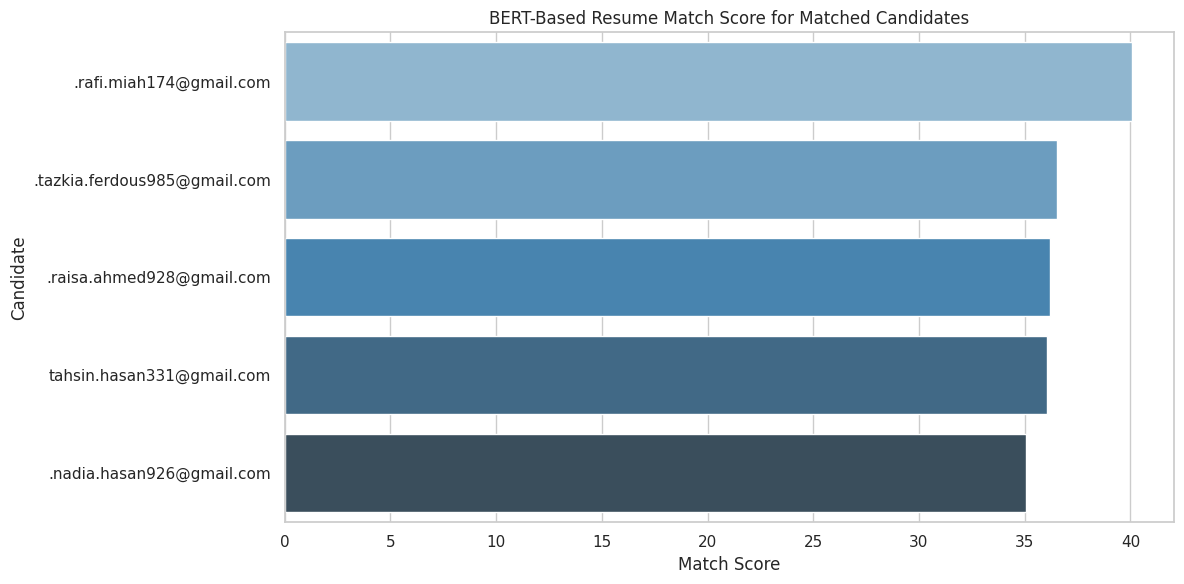

In [ ]:
# Visualization
if dff.empty:
    print("DataFrame is empty. No further processing will be done.")
    # Removed exit() to prevent stopping the kernel
else:
  plt.figure(figsize=(12, 6))
  sns.barplot(data=dff, x="MatchScore", y="Email", palette="Blues_d")
  plt.title("BERT-Based Resume Match Score for Matched Candidates")
  plt.xlabel("Match Score")
  plt.ylabel("Candidate")
  plt.tight_layout()
  plt.show()

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

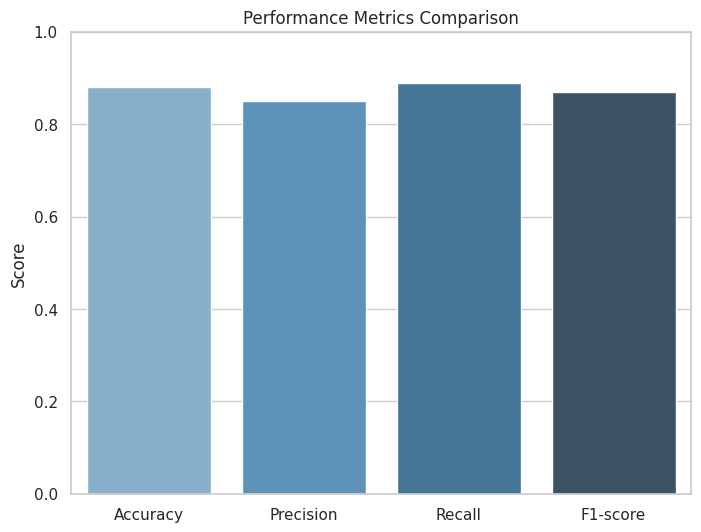

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example metric values
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
values = [0.88, 0.85, 0.89, 0.87]

# Create bar plot
sns.set(style="whitegrid")
plt.figure(figsize=(8, 6))
sns.barplot(x=metrics, y=values, palette='Blues_d')

plt.title('Performance Metrics Comparison')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.show()


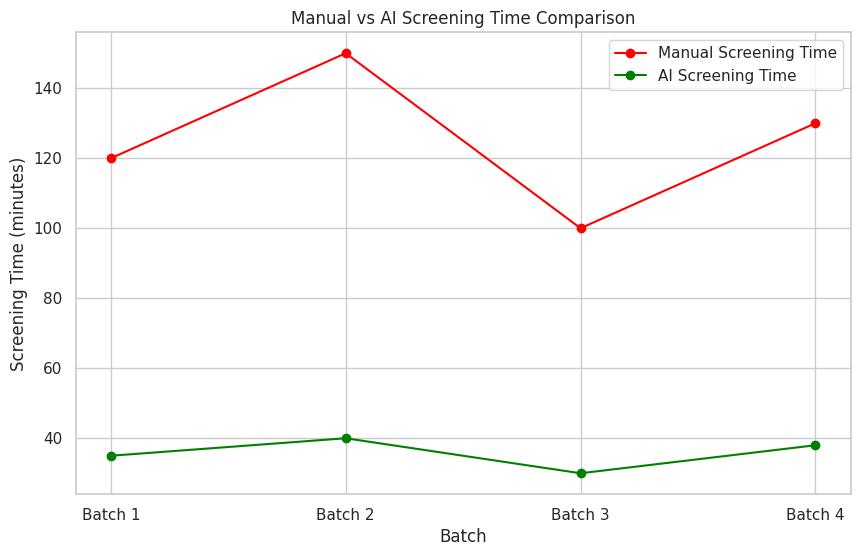

In [ ]:
import matplotlib.pyplot as plt

# Example times (in minutes) for each batch
batches = ['Batch 1', 'Batch 2', 'Batch 3', 'Batch 4']
manual_time = [120, 150, 100, 130]
ai_time = [35, 40, 30, 38]

plt.figure(figsize=(10, 6))
plt.plot(batches, manual_time, marker='o', label='Manual Screening Time', color='red')
plt.plot(batches, ai_time, marker='o', label='AI Screening Time', color='green')

plt.title('Manual vs AI Screening Time Comparison')
plt.xlabel('Batch')
plt.ylabel('Screening Time (minutes)')
plt.legend()
plt.grid(True)
plt.show()


**Pie Chart: Top Skills Frequency**

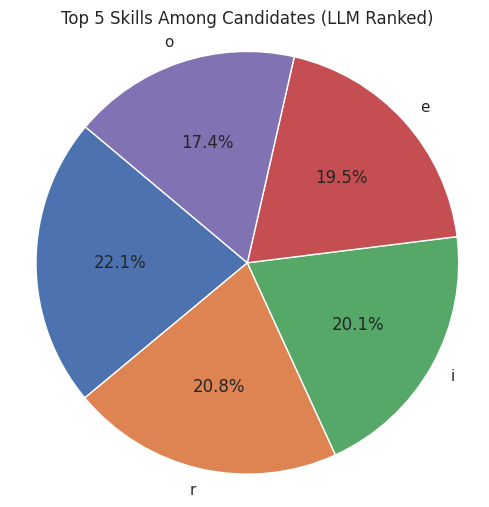

In [ ]:
from collections import Counter
if dff.empty:
    print("DataFrame is empty. No further processing will be done.")
    # Removed exit() to prevent stopping the kernel
else:
  all_skills = [skill for skills in dff["Skills"] for skill in skills]
  skill_counts = Counter(all_skills)
  top_skills = dict(skill_counts.most_common(5))  # Top 5

  plt.figure(figsize=(6, 6))
  plt.pie(top_skills.values(), labels=top_skills.keys(), autopct='%1.1f%%', startangle=140)
  plt.title("Top 5 Skills Among Candidates (LLM Ranked)")
  plt.axis('equal')
  plt.show()

**Stacked Bar: Skills per Candidate**

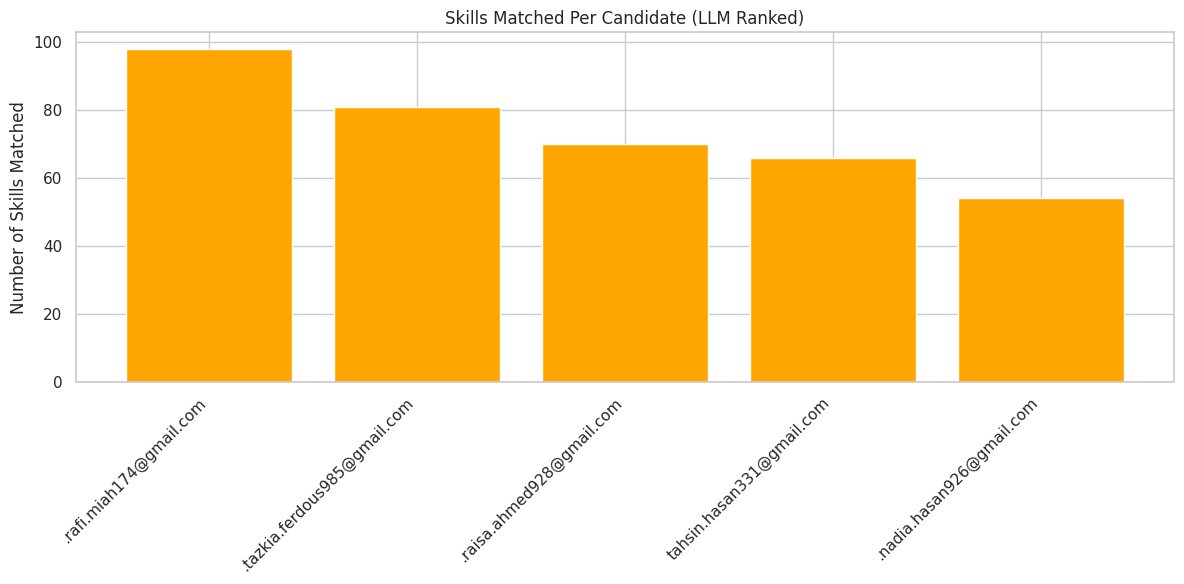

In [ ]:
if dff.empty:
    print("DataFrame is empty. No further processing will be done.")
    # Removed exit() to prevent stopping the kernel
else:
  dff["SkillCount"] = dff["Skills"].apply(len)
  plt.figure(figsize=(12, 6))
  plt.bar(dff["Email"], dff["SkillCount"], color='orange')
  plt.xticks(rotation=45, ha='right')
  plt.ylabel("Number of Skills Matched")
  plt.title("Skills Matched Per Candidate (LLM Ranked)")
  plt.tight_layout()
  plt.show()

**Plot bar chart of Match Scores(Seaborn)**

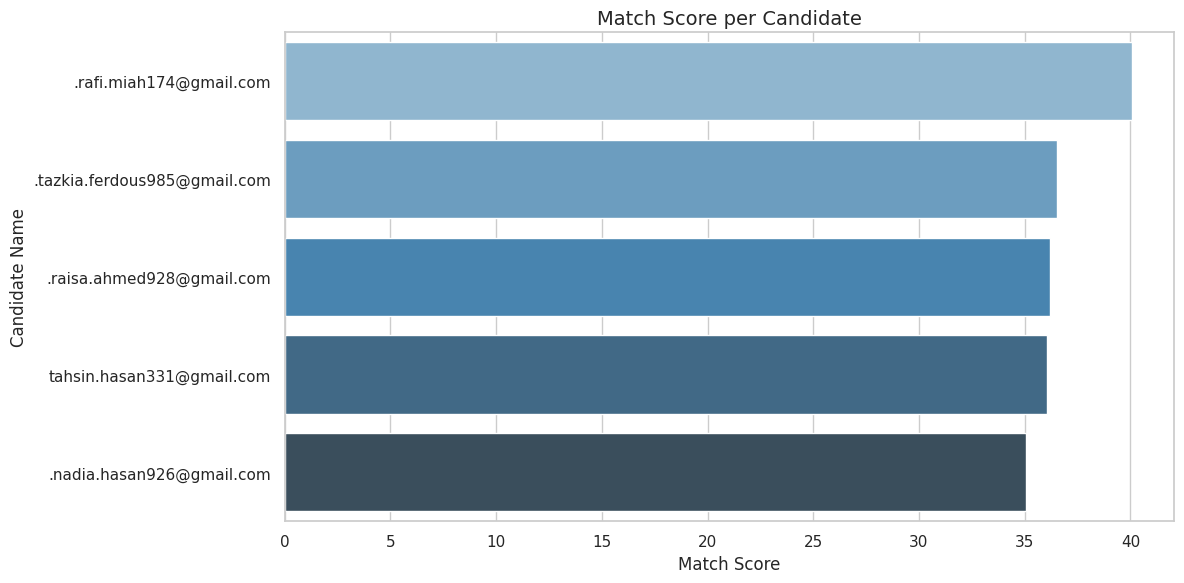

In [ ]:
if dff.empty:
    print("DataFrame is empty. No further processing will be done.")
    # Removed exit() to prevent stopping the kernel
else:
  plt.figure(figsize=(12, 6))
  sns.barplot(data=dff, y="Email", x="MatchScore", palette="Blues_d")
  plt.title("Match Score per Candidate", fontsize=14)
  plt.xlabel("Match Score")
  plt.ylabel("Candidate Name")
  plt.tight_layout()
  plt.show()


Vertical Bar Chart

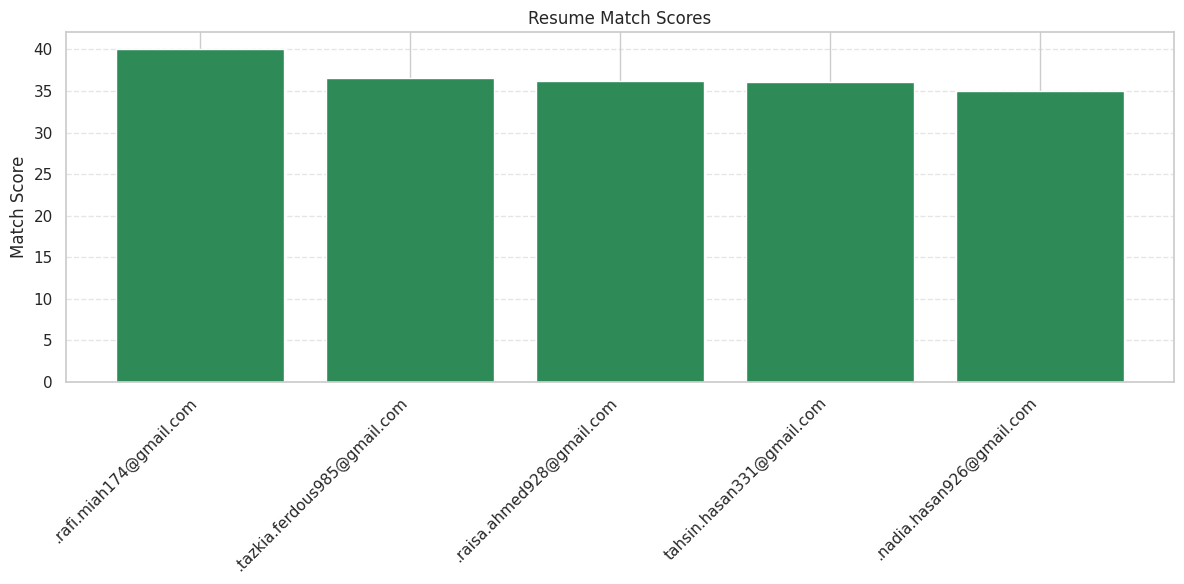

In [ ]:
if dff.empty:
    print("DataFrame is empty. No further processing will be done.")
    # Removed exit() to prevent stopping the kernel
else:
  plt.figure(figsize=(12, 6))
  plt.bar(dff["Email"], dff["MatchScore"], color='seagreen')
  plt.xticks(rotation=45, ha='right')
  plt.ylabel("Match Score")
  plt.title("Resume Match Scores")
  plt.grid(axis='y', linestyle='--', alpha=0.5)
  plt.tight_layout()
  plt.show()


**Scatter Plot: Match Score vs. Experience (Matplotlib)**

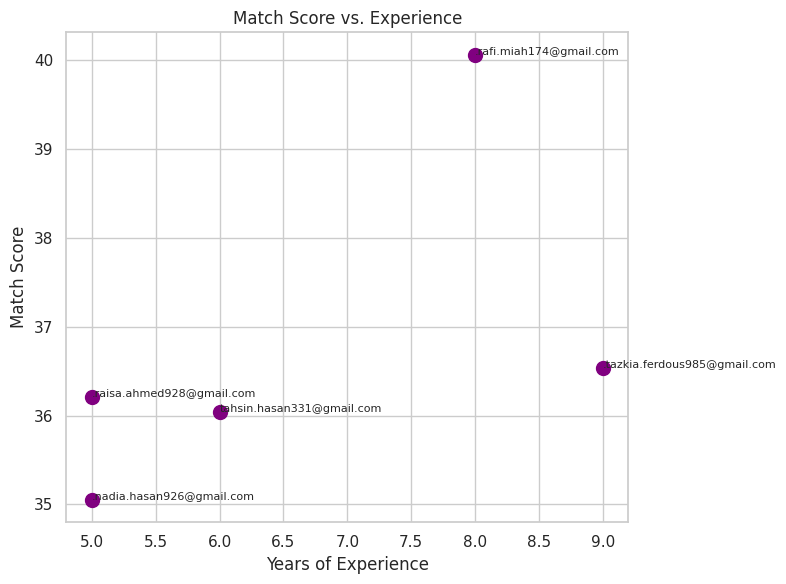

In [ ]:
if dff.empty:
    print("DataFrame is empty. No further processing will be done.")
    # Removed exit() to prevent stopping the kernel
else:
  plt.figure(figsize=(8, 6))
  plt.scatter(dff["ExperienceYears"], dff["MatchScore"], color='purple', s=100)
  for i, row in dff.iterrows():
      plt.text(row["ExperienceYears"], row["MatchScore"], row["Email"], fontsize=8)
  plt.xlabel("Years of Experience")
  plt.ylabel("Match Score")
  plt.title("Match Score vs. Experience")
  plt.grid(True)
  plt.tight_layout()
  plt.show()


**Scatter Plot: Match Score vs. Experience (Seaborn)**

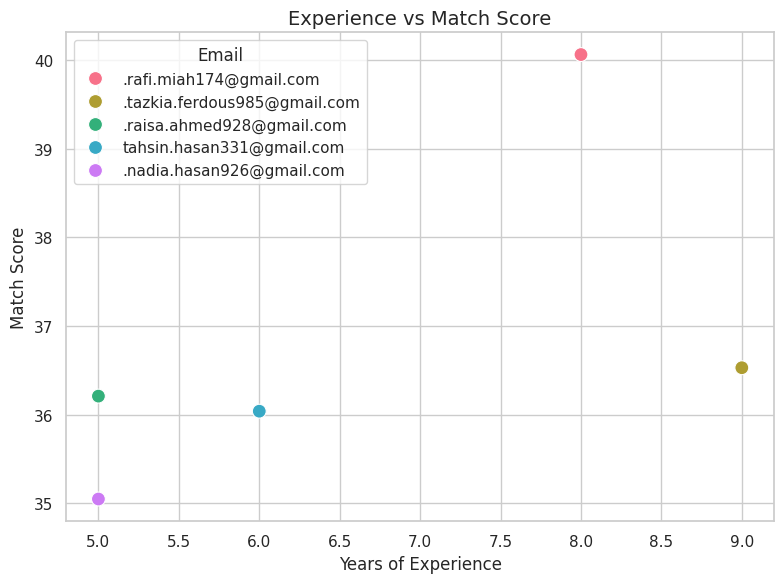

In [ ]:
if dff.empty:
    print("DataFrame is empty. No further processing will be done.")
    # Removed exit() to prevent stopping the kernel
else:
  plt.figure(figsize=(8, 6))
  sns.scatterplot(data=dff, x="ExperienceYears", y="MatchScore", hue="Email", s=100, palette="husl")
  plt.title("Experience vs Match Score", fontsize=14)
  plt.xlabel("Years of Experience")
  plt.ylabel("Match Score")
  plt.grid(True)
  plt.tight_layout()
  plt.show()


** Boxplot: Distribution of Match Scores**

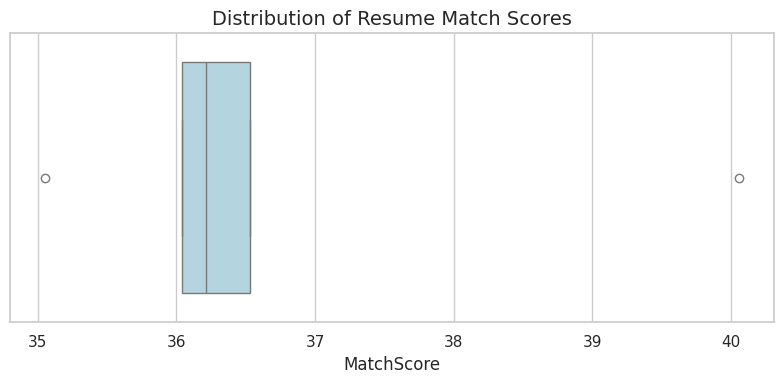

In [ ]:
if dff.empty:
    print("DataFrame is empty. No further processing will be done.")
    # Removed exit() to prevent stopping the kernel
else:
  plt.figure(figsize=(8, 4))
  sns.boxplot(data=dff, x="MatchScore", color="lightblue")
  plt.title("Distribution of Resume Match Scores", fontsize=14)
  plt.tight_layout()
  plt.show()


# **LLM: Mistral - 7B**

In [ ]:
pip install ollama


In [ ]:
!curl -fsSL https://ollama.com/install.sh | sh

# Run Ollama in the background
import subprocess
import os

# Set OLLAMA_HOST to bind to all network interfaces, important for Colab
os.environ['OLLAMA_HOST'] = '0.0.0.0:11434'

# Start Ollama server in a separate process
# The Popen call is non-blocking, allowing the notebook to continue.
ollama_process = subprocess.Popen(['ollama', 'serve'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

print("Ollama server started in the background.")

>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading Linux amd64 bundle
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
Ollama server started in the background.


In [ ]:
!ollama pull mistral

In [ ]:
import subprocess

try:
    output = subprocess.check_output(["ollama", "--version"])
    print("Ollama installed:", output.decode())
except Exception as e:
    print("Ollama NOT installed.", e)


In [ ]:
import requests, re, json
from time import sleep

OLLAMA_URL = "http://localhost:11434/api/generate"
MODEL_NAME = "mistral"   # or "mistral:7b-instruct" if you pulled that exact tag

def parse_json_from_text(text):
    m = re.search(r'\{.*\}', text, flags=re.DOTALL)
    if not m:
        return None
    txt = m.group(0).replace("'", '"')
    try:
        return json.loads(txt)
    except:
        return None

def get_llm_score_ollama(resume_summary, job_description, retries=2):
    prompt = f"""You are an expert HR analyst. Rate how well this resume fits the job description.
Return ONLY a JSON object like: {{ "score": <0-100>, "reason": "<short reason>" }}

Job: {job_description[:2000]}

Resume: {resume_summary[:2000]}

Return JSON:"""

    payload = {
        "model": MODEL_NAME,
        "prompt": prompt,
        "stream": False
    }

    for attempt in range(retries+1):
        try:
            r = requests.post(OLLAMA_URL, json=payload, timeout=120)
            r.raise_for_status()
            data = r.json()
            # The API returns text in different keys depending on version; check structure:
            # Often final text is in data.get("response") or data["choices"][0]["message"]["content"]
            # Try common fields:
            text = None
            if isinstance(data, dict):
                # check common keys
                text = data.get("response") or data.get("text")
                if not text and "choices" in data:
                    text = data["choices"][0].get("message", {}).get("content") if data["choices"] else None
                if not text and "complete" in data:
                    # some versions return a list of chunks; join them
                    if isinstance(data["complete"], list):
                        text = "".join([c.get("text","") for c in data["complete"]])
            if text is None:
                # fallback: try the raw text
                text = r.text

            parsed = parse_json_from_text(text)
            if parsed and "score" in parsed:
                parsed["score"] = int(round(float(parsed["score"]))) if parsed["score"] is not None else None
                return parsed
            # fallback: try to extract a number
            m = re.search(r'(\d{1,3})', text)
            score = int(m.group(1)) if m else None
            return {"score": score, "reason": text.strip()}
        except Exception as e:
            if attempt < retries:
                sleep(1)
                continue
            return {"score": None, "reason": f"Error: {e}"}


In [ ]:
results = []
for idx, row in dff.iterrows():
    # Replaced create_resume_summary with the existing generate_resume_text function
    summary = generate_resume_text(row)
    out = get_llm_score_ollama(summary, job_description)
    results.append(out)
    if (idx+1) % 20 == 0:
        print(f"Processed {idx+1}/{len(dff)}")

dff["LLM_MatchScore"] = [r["score"] for r in results]
dff["LLM_Reason"] = [r["reason"] for r in results]

In [ ]:
dff = dff.sort_values(by="LLM_MatchScore", ascending=False).reset_index(drop=True)
dff = dff.head(5)
dff

,Filename,Category,Email,Phone,CGPA,ExperienceYears,Skills,Education,Projects,Achievements,ExperienceDetails,Source,Level,Similarity,SkillCount,MatchScore,LLM_MatchScore,LLM_Reason
0,rafi995.txt,Systems Administrator,.rafi.miah174@gmail.com,8801675885627,3.51,8.0,"linux, vmware, network configuration, system m...","Daffodil International University, BSc in Comp...","Project NeuralNet: used vmware, linux — automa...",Best Employee Award at previous job\nGoogle De...,Technical Writer at Bkash — 2022–2025\nCyberse...,Synthetic,Expert,0.400803,98,40.06,85,The candidate has a strong background in compu...
1,nadia397.txt,Systems Administrator,.nadia.hasan926@gmail.com,8801874686398,3.34,5.0,"virtualization, system monitoring, powershell,...","Daffodil International University, BBA in Huma...","Project Atlas: used hyper-v, system monitoring...",Champion in National Hackathon Bangladesh\nTop...,Embedded Systems Engineer at Brain Station 23 ...,Synthetic,Expert,0.375628,54,35.05,80,"The candidate has experience with Python, mach..."
2,tazkia811.txt,Systems Administrator,.tazkia.ferdous985@gmail.com,8801491298358,3.84,9.0,"network configuration, linux, windows server, ...","BUET, BSc in Electrical and Electronic Enginee...","Project Optimus: used virtualization, hyper-v ...",Google Developer Group Dhaka Volunteer,Game Developer at Therap BD — 2024–2025\nDigit...,Synthetic,Expert,0.344074,81,36.53,70,The resume demonstrates experience with releva...
3,raisa886.txt,Systems Administrator,.raisa.ahmed928@gmail.com,8801493038035,3.9,5.0,"windows server, powershell, hyper-v, virtualiz...","BUET, BSc in Electrical and Electronic Enginee...","Project Nova: used powershell, system monitori...",Completed Coursera Professional Certificate\nG...,Bioinformatics Specialist at Enosis Solutions ...,Synthetic,Expert,0.390137,70,36.21,70,The candidate has experience with several rele...
4,tahsin449.txt,Systems Administrator,tahsin.hasan331@gmail.com,8801524579889,3.65,6.0,"virtualization, vmware, system monitoring, hyp...","SUST, BSc in Computer Science and Engineering ...","Project Optimus: used virtualization, hyper-v,...",Google Developer Group Dhaka Volunteer\nTop pe...,UI/UX Designer at Brain Station 23 — 2024–2025...,Synthetic,Expert,0.375486,66,36.04,60,The candidate has experience with virtualizati...


In [ ]:
import plotly.express as px

fig = px.bar(
    dff,
    x="LLM_MatchScore",
    y="Email",
    orientation="h",
    title="Resume Match Score Leaderboard",
    hover_data=["Skills", "ExperienceYears"],
    color="LLM_MatchScore",
    color_continuous_scale="Blues"
)
fig.update_layout(height=600)
fig.show()


In [ ]:
dff["ProjectCount"] = dff["Projects"].fillna("").apply(lambda x: len(x.split("\n")))
dff["AchievementCount"] = dff["Achievements"].fillna("").apply(lambda x: len(x.split("\n")))

fig = px.scatter(
    dff,
    x="ExperienceYears",
    y="ProjectCount",
    size="AchievementCount",
    color="LLM_MatchScore",
    hover_name="Email",
    title="Experience vs Projects vs Achievements",
    labels={"ExperienceYears": "Years of Experience", "ProjectCount": "Projects"},
    size_max=40,
    color_continuous_scale="Viridis"
)
fig.show()


In [ ]:
import pandas as pd

# Get unique skill set
all_skills = sorted({s.lower() for lst in dff["Skills"] for s in lst})

# Create binary matrix
skill_matrix = pd.DataFrame(0, index=dff["Email"], columns=all_skills)

for idx, row in dff.iterrows():
    for skill in row["Skills"]:
        skill_matrix.loc[row["Email"], skill.lower()] = 1

fig = px.imshow(
    skill_matrix,
    title="Skill Coverage Heatmap",
    aspect="auto",
    color_continuous_scale="Blues"
)
fig.show()


In [ ]:
import plotly.express as px
import pandas as pd

df_compare = dff.copy()

fig = px.line(
    df_compare.melt(id_vars="Email", value_vars=["MatchScore", "LLM_MatchScore"]),
    x="Email",
    y="value",
    color="variable",
    markers=True,
    title="Match Score Comparison: TF-IDF vs LLM",
    labels={"value": "Match Score", "variable": "Model"}
)

fig.update_layout(xaxis={'categoryorder':'total descending'}, height=500)
fig.show()
